In [6]:
from model.model import Autoencoder, CustomTransformerModel, EncocderWrapper
from utils.data_loader import get_mnist_random_loader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
autoencoder_path = "model/autoencoder_mnist.pth"
latent_dim = 64
device = "cuda"

In [8]:
autoencoder = Autoencoder(latent_dim).to(device)
autoencoder.load_state_dict(torch.load(autoencoder_path))
autoencoder.to(device)
autoencoder.eval()
encoder = autoencoder.encoder
encoder = EncocderWrapper(encoder)

encoder = encoder.to(device)
model = CustomTransformerModel(encoder, 2, device=device)

criterion = nn.CrossEntropyLoss()

batch_size = 16

/tmp/ipykernel_104147/4050518009.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(autoencoder_path))


In [9]:
from tqdm import tqdm
import time

def test(lr=1e-3, num_epochs=40, log_step=500):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    start_time = time.time()

    losses = []
    accuracies = []

    for epoch in range(num_epochs):
        total_correct = 0
        total_samples = 0
        total_loss = 0

        loader = get_mnist_random_loader(batch_size=batch_size, num_samples=10000)

        for batch_idx, (images, labels, pred_image, pred_label) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
            images, labels, pred_image, pred_label = images.to(device, non_blocking=True), labels.to(device, non_blocking=True), pred_image.to(device, non_blocking=True), pred_label.to(device, non_blocking=True)
            outputs = model.forward(images, labels, pred_image)
            
            pred_label = pred_label.view(-1)
            loss = criterion(outputs, pred_label)
            
            optimizer.zero_grad()   # Reset gradient
            loss.backward()         # Backpropagation

            clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()        # Update parameters

            total_loss += loss.item()

            with torch.no_grad():
                predicted = torch.argmax(outputs, dim=1)
                correct = (predicted == pred_label).sum().item()
                total = pred_label.size(0)
                total_correct += correct
                total_samples += total

        avg_loss = total_loss / total_samples
        accuracy = total_correct / total_samples
        losses.append(avg_loss)
        accuracies.append(accuracy)

        total_grad_norm = 0.0
        grad_param_count = 0
        for param in model.parameters():
            if param.grad is not None:
                total_grad_norm += param.grad.norm().item()
                grad_param_count += 1

        avg_grad_norm = total_grad_norm / grad_param_count if grad_param_count > 0 else 0.0

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}, Avg Gradient Norm: {avg_grad_norm:.6f}")

        elapsed_time = time.time() - start_time
        avg_time_per_epoch = elapsed_time / (epoch + 1)
        remaining_time = avg_time_per_epoch * (num_epochs - epoch - 1)
        print(f"Estimated time left: {remaining_time // 60:.0f} minutes {remaining_time % 60:.0f} seconds")
    return avg_loss, accuracy, losses, accuracies

In [10]:
learning_rates = [1e-4]
num_epochs = 100
batches_per_epoch = 10000

results = {}    
for lr in learning_rates:
    model = CustomTransformerModel(encoder, 2, device)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    avg_loss, accuracy, losses, accuracies = test(lr=lr, num_epochs=num_epochs)

torch.save(model.state_dict(), "model/transformer.pth")

Epoch 1/100: 100%|██████████| 625/625 [00:04<00:00, 156.17it/s]


Epoch [1/100], Loss: 0.0438, Accuracy: 0.50, Avg Gradient Norm: 0.024462
Estimated time left: 11 minutes 19 seconds


Epoch 2/100: 100%|██████████| 625/625 [00:04<00:00, 153.84it/s]


Epoch [2/100], Loss: 0.0435, Accuracy: 0.50, Avg Gradient Norm: 0.017952
Estimated time left: 11 minutes 8 seconds


Epoch 3/100: 100%|██████████| 625/625 [00:04<00:00, 154.18it/s]


...

Epoch [98/100], Loss: 0.0046, Accuracy: 0.98, Avg Gradient Norm: 0.025897
Estimated time left: 0 minutes 13 seconds


Epoch 99/100: 100%|██████████| 625/625 [00:04<00:00, 152.07it/s]


Epoch [99/100], Loss: 0.0047, Accuracy: 0.98, Avg Gradient Norm: 0.029840
Estimated time left: 0 minutes 7 seconds


Epoch 100/100: 100%|██████████| 625/625 [00:04<00:00, 153.30it/s]

Epoch [100/100], Loss: 0.0045, Accuracy: 0.98, Avg Gradient Norm: 0.000988
Estimated time left: 0 minutes 0 seconds


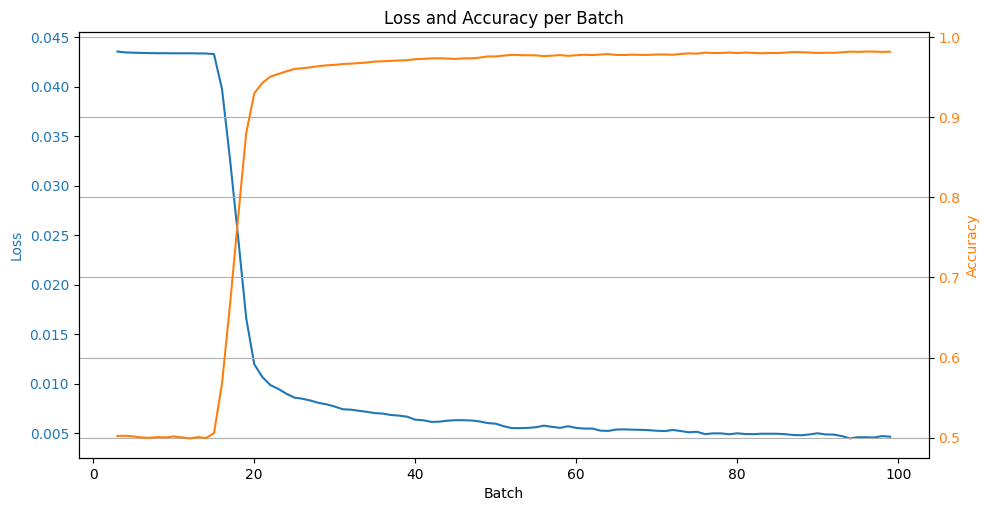

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

smoothed_losses = pd.Series(losses).rolling(window=4).mean()
smoothed_accuracies = pd.Series(accuracies).rolling(window=4).mean()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Batch')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.plot(smoothed_losses, label='Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:orange')
ax2.plot(smoothed_accuracies, label='Accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Loss and Accuracy per Epoch')
plt.grid(True)
plt.savefig("accuracy.pdf")
plt.show()

In [12]:
class TestPlotter:
    def __init__(self, model, loader, device):
        self.model = model
        self.loader = loader
        self.device = device

    def measure_accuracy(self, num_images=200):
        self.model.eval()
        total_correct = 0
        total_images = 0

        with torch.no_grad():
            for images, labels, pred_images, pred_labels in self.loader:
                images, labels, pred_images, pred_labels = images.to(self.device), labels.to(self.device), pred_images.to(self.device), pred_labels.to(self.device)
                outputs = self.model.forward(images, labels, pred_images)
                predicted_labels = torch.argmax(outputs, dim=1)
                print(predicted_labels, pred_labels)
                correct = (predicted_labels == pred_labels.view(-1)).sum().item()
                total_correct += correct
                total_images += pred_labels.size(0)
                if total_images >= num_images:
                    break

        accuracy = total_correct / total_images
        print(f"Accuracy over {total_images} images: {accuracy:.4f}")

# Usage
loader = get_mnist_random_loader(batch_size=batch_size)
test_plotter = TestPlotter(model, loader, device)
test_plotter.measure_accuracy(num_images=10000)


tensor([1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1], device='cuda:0') tensor([1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1], device='cuda:0')
tensor([1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1], device='cuda:0') tensor([1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1], device='cuda:0')
tensor([0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1], device='cuda:0') tensor([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1], device='cuda:0')
tensor([1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0') tensor([1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
tensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0], device='cuda:0') tensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0], device='cuda:0')
tensor([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0], device='cuda:0') tensor([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0], device='cuda:0')
tensor([0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1], device='cuda:0') tensor([0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 